In [1]:
import sys
import os
from pathlib import Path
import pickle
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import linregress
from xarray.coding.times import decode_cf_datetime

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Project paths
try:
    project_root = Path.cwd().parent
except NameError:
    project_root = Path('/scistor/guest/gbb083/AeroCom')
py_dir = project_root / 'py'
if str(py_dir) not in sys.path:
    sys.path.insert(0, str(py_dir))
sys.path.append(py_dir)
import functions
import cameo_toolbox as ct
import aerocom_data
import notebook_setup as setup

print(f'Project root: {project_root}')
print(f'Python dir:   {py_dir}')

Project root: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom
Python dir:   /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/py


In [2]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
EXCLUDE_MODELS = ['GEOS-i33p2-met2010_AP3-CTRL-2010','GISS-ModelE2p1p1-OMA_AP3-CTRL-2010','GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010','GISS-ModelE2p1p1-MATRIX_AP3-CTRL','NorESM2-met2010_AP3-CTRL-v3']  

# Derived variables computed after regional/temporal aggregation.
# AAOD analysis uses BC+OA only; total-aerosol lifetime is not required.
DERIVED_VAR_AFTER_AGG = ['lifetime_SS']


# Deposition-based lifetime option
USE_DEPOSITION_FOR_LIFETIME = False  # True → lifetime = load / deposition; False → lifetime = load / emission

SAVE_FIGURE = False
FIGURE_DIR = project_root / 'figure'
TABLE_DIR = project_root / 'tables'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
USE_PICKLE = False

# Shared regional seasonal cache (see py/build_regional_aggregates.py).
# True  → skip NetCDF load / aggregate / POLDER / GPCP / homogenize;
#         rebuild model_seasonal + obs from parquet.
# False → full pipeline (optional SAVE_AGG_CACHE refreshes the parquet).
AGG_PARQUET = TABLE_DIR / 'regional_seasonal_aggregates_ss.parquet'
USE_AGG_CACHE = False
SAVE_AGG_CACHE = False
p = Path(AGG_PARQUET)
if not p.is_file():
    USE_AGG_CACHE = False
    SAVE_AGG_CACHE = True

# MAC–x regression (x = SSA or 1-SSA, as in SSA_MEC_scatter_plot.ipynb):
#   MAC_X_COL = 'SSA'   -> MAC = F * SSA  (+ b unless INTERCEPT_0)
#   MAC_X_COL = '1-SSA' -> MAC = A * (1-SSA) (+ b unless INTERCEPT_0)
#                         Theory: MAC = MEC*(1-SSA) prefers INTERCEPT_0=True
MAC_X_COL = '1-SSA'  # or '1-SSA'
#   INTERCEPT_0 = False -> OLS with intercept (default)
#   INTERCEPT_0 = True  -> through origin (uncentered R²)
INTERCEPT_0 = True

def short_model_name(model):
    """Compact tick label: strip common AeroCom CTRL suffixes."""
    name = str(model)
    for suffix in (
        '_AP3-CTRL2016-PD', '_AP3-CTRL2016', '_AP3-CTRL-2010',
        '_AP3-CTRL2019', '_AP3-CTRL', '-met2010',
    ):
        name = name.replace(suffix, '')
    return name

# Zhong et al. POLDER-GRASP homogenization of regional AAOD used for E_C.
POLDER_HOMOGENIZE = True

# Homogenize regional SSA_obs the same way as AAOD_obs (item 2): fit
# sampled = a * regional + b from models, then invert with the raw
# POLDER-sampled SSA mean.
SSA_POLDER_HOMOGENIZE = True



In [ ]:

REGIONS = {
    'global': {
        'surface_type': 'ocean',
        'lon_range': (0, 360), 'lat_range': (-90, 90),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'ARCO': {
        'surface_type': 'ocean',
        'lon_range': (0, 360), 'lat_range': (60, 90),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'NPO': {
        'surface_type': 'ocean',
        'lon_range': (120, 260), 'lat_range': (20, 60),
        'time_slice': ('2010-01-01', '2010-02-28'), 'edge_weighted': False, # CHOSE THE LOW DSM 
    },
    'TPO': {
        'surface_type': 'ocean',
        'lon_range': (120, 280), 'lat_range': (-20, 20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False, 
    },
    'SPO': {
        'surface_type': 'ocean',
        'lon_range': (120, 290), 'lat_range': (-60, -20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'NAO': {
        'surface_type': 'ocean',
        'lon_range': (280, 360), 'lat_range': (20, 60),
        'time_slice':  ('2010-01-01', '2010-02-28'), 'edge_weighted': False,
    },
    'TAO': {
        'surface_type': 'ocean',
        'lon_range': (290, 360), 'lat_range': (-20, 20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'SAO': {
        'surface_type': 'ocean',
        'lon_range': (290, 360), 'lat_range': (-60, -20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'TIO': {
        'surface_type': 'ocean',
        'lon_range': (20, 120), 'lat_range': (-20, 20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'SIO': {
        'surface_type': 'ocean',
        'lon_range': (20, 120), 'lat_range': (-60, -20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'ANTAO': {
        'surface_type': 'ocean',
        'lon_range': (0, 360), 'lat_range': (-90, -60),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
}
# Source regions used for the main Fig. 3-style decomposition.
SOURCE_REGIONS = ['NAO', 'NPO']
OUTFLOW_REGION = 'outflow_af'
# OUTFLOW_SOURCE = 'africa'
# Only these regions are masked/aggregated/used in the notebook.
ANALYSIS_REGIONS = SOURCE_REGIONS + [OUTFLOW_REGION]

# Shared per-region color palette (used across all plots in this notebook).
REGION_COLORS = {
    'afriNAOca': '#ff7f0e', 'NPO': '#2ca02c', 'outflow_af': '#9467bd',
    'indonesia_peatland': '#8c564b',
    'boreal_na_west': '#1f77b4',
}


print('\n--- Active configuration ---')
print(f'  MAC_X_COL            = {MAC_X_COL!r}')
print(f'  INTERCEPT_0          = {INTERCEPT_0}  '
      f"({'through origin' if INTERCEPT_0 else 'OLS with intercept'})")
print(f'  POLDER_HOMOGENIZE    = {POLDER_HOMOGENIZE}')  
print(f'  USE_DEPOSITION_FOR_LIFETIME = {USE_DEPOSITION_FOR_LIFETIME}  ',
      f"({'load/deposition' if USE_DEPOSITION_FOR_LIFETIME else 'load/emission'})",
      f'(CAM5 long lifetimes filtered here)')
print(f'  EXCLUDE_MODELS      = {EXCLUDE_MODELS}')
print(f'  ANALYSIS_REGIONS     = {ANALYSIS_REGIONS}')
print(f'  DERIVED_VAR_AFTER_AGG= {DERIVED_VAR_AFTER_AGG}')
print(f'  USE_AGG_CACHE         = {USE_AGG_CACHE}')
print(f'  AGG_PARQUET           = {AGG_PARQUET}')
print(f'  SAVE_FIGURE          = {SAVE_FIGURE}')
print(f'  FIGURE_DIR           = {FIGURE_DIR}')
print(f'  TABLE_DIR            = {TABLE_DIR}')



--- Active configuration ---
  MAC_X_COL            = '1-SSA'
  INTERCEPT_0          = True  (through origin)
  POLDER_HOMOGENIZE    = True


NameError: name 'POST_AGG_LIFETIME_MIN_DAYS' is not defined

In [31]:
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping NetCDF load')
else:
    VARIABLES = [
        'od440aer', 'od550aer','od870aer', 'od865aer', 
        'abs550aer','od550ss','od550so4',
        'emiss', 'loadbc', 'loaddust', 'loadoa', 'loadso4', 
        'loadss','depso4', 'depss','precip'
    ]
    variables_pre_aggregated = [
        'MEC', 'MAC', 'SSA', 'AE', 'precip'
    ]

    print('Loading monthly data from processed NetCDF files...')
    raw_data = aerocom_data.load_monthly_data_from_netcdf(
        output_base_dir=str(project_root / 'Data' / 'AP3_processed_monthly'),
        variables=VARIABLES,
    )

    # Apply model exclusion list before any processing
    missing_excluded = [m for m in EXCLUDE_MODELS if m not in raw_data]
    if missing_excluded:
        print(f'Warning: excluded models not found in data: {missing_excluded}')
    models = sorted([m for m in raw_data.keys() if m not in EXCLUDE_MODELS])
    actually_excluded = [m for m in EXCLUDE_MODELS if m in raw_data]
    print(f'Number of models: {len(models)} (excluded {len(actually_excluded)}: {actually_excluded})')

    # Document SOA availability in processed NetCDF
    _available_vars = sorted({
        p.name for p in (project_root / 'Data' / 'AP3_processed_monthly').iterdir()
        if p.is_dir()
    }) if (project_root / 'Data' / 'AP3_processed_monthly').exists() else [] 
    print(f'Processed monthly variables: {len(_available_vars)} directories')


Loading monthly data from processed NetCDF files...
Loaded 363 NetCDF files for 30 models from /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/AP3_processed_monthly
Number of models: 26 (excluded 4: ['GISS-ModelE2p1p1-OMA_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL', 'NorESM2-met2010_AP3-CTRL-v3'])
Processed monthly variables: 29 directories


In [32]:
# OD_SS = 'od550ss'
# ssAOD_r 
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping normalize/sums')
else:
    data = {}
    for m in models:
        normalized = {}
        for var in VARIABLES:
            if raw_data[m].get(var) is None:
                continue
            try:
                normalized[var] = aerocom_data.normalize_dataset_time(raw_data[m][var], var_hint=f'{m}/{var}', year=2010)
            except Exception as e:
                print(f'  Failed to normalize {m}/{var}: {e}')
                normalized[var] = None
        data[m] = normalized
    n_emiss = sum(1 for m in models if data[m].get('emiss') is not None)
    n_depss = sum(1 for m in models if data[m].get('depss') is not None)
    n_odss = sum(1 for m in models if data[m].get('od550ss') is not None)
    print(f'  od550ss available: {n_odss}/{len(models)} ')
    print(f'  ses salt emission available: {n_emiss}/{len(models)} models ')
    print(f'  ses salt deposition available:{n_depss}/{len(models)} models ')

    # -- add target_model list from the model that exits both in emiss and od550ss--
    tar_var = "depss" if USE_DEPOSITION_FOR_LIFETIME else 'od550ss'
    target_models = [m for m in models if data[m].get(tar_var) is not None and data[m].get('od550ss') is not None]
 

  od550ss available: 24/26 
  ses salt emission available: 23/26 models 
  ses salt deposition available:12/26 models 


<xarray.Dataset> Size: 520kB
Dimensions:  (lon: 120, lat: 90, time: 12)
Coordinates:
  * lon      (lon) float64 960B 1.5 4.5 7.5 10.5 ... 349.5 352.5 355.5 358.5
  * lat      (lat) float64 720B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * time     (time) datetime64[us] 96B 2010-01-01 2010-02-01 ... 2010-12-01
Data variables:
    loadss   (time, lat, lon) float32 518kB dask.array<chunksize=(12, 90, 120), meta=np.ndarray>


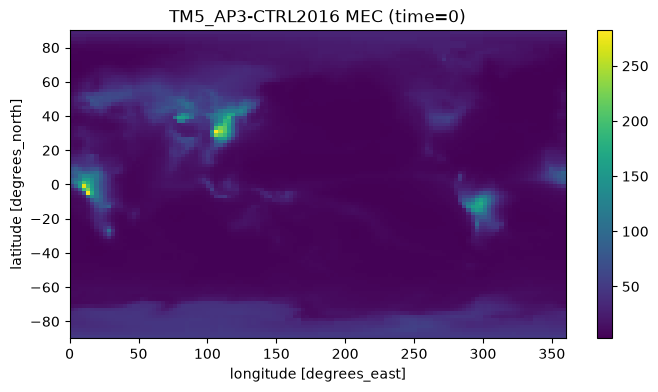

In [15]:
od = data[m].get('od550aer')
ld = data[m].get('loadss')

if od is None or ld is None:
    raise KeyError(f"Missing od550aer or loadss for model {m}")

MEC = od / (ld * 1e3)
print(ld)
mec_da = od['od550aer'] / (ld['loadss'] * 1e3)
mec_da.isel(time=0).plot(figsize=(8, 4))
plt.title(f"{m} MEC (time=0)")
plt.show()

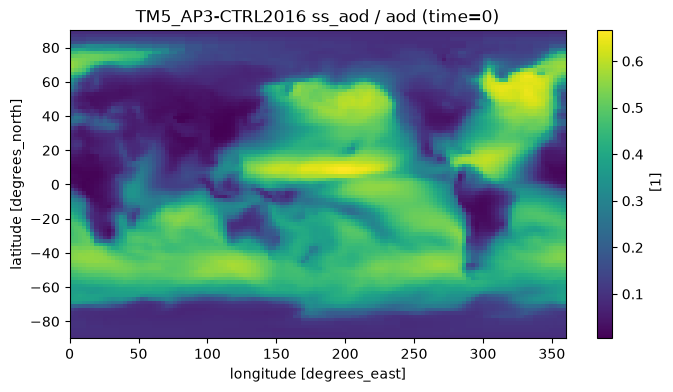

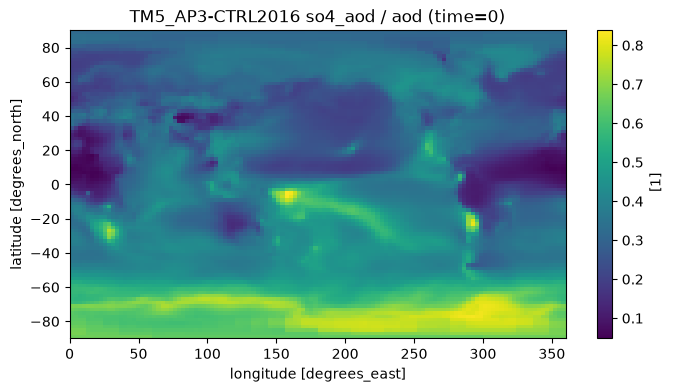

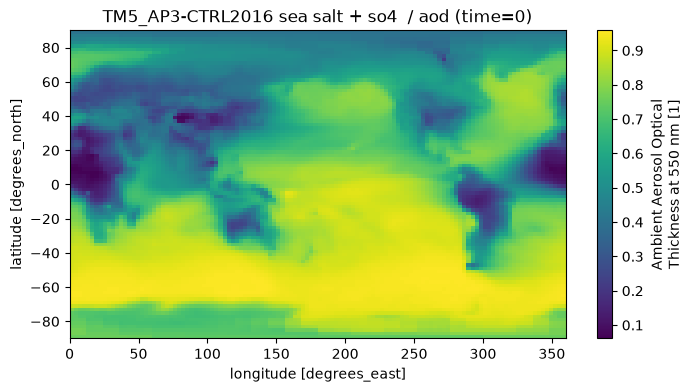

In [18]:
odSS = data[m].get('od550ss')
ss_r = odSS['od550ss'] / od['od550aer']
ss_r.isel(time=0).plot(figsize=(8, 4))
plt.title(f"{m} ss_aod / aod (time=0)")
plt.show()
odS04 = data[m].get('od550so4')
so4_r = odS04['od550so4'] / od['od550aer']
so4_r.isel(time=0).plot(figsize=(8, 4))
plt.title(f"{m} so4_aod / aod (time=0)")
plt.show()
ssso4_r = (odSS['od550ss'] + odS04['od550so4']) / od['od550aer']
ssso4_r.isel(time=0).plot(figsize=(8, 4))
plt.title(f"{m} sea salt + so4  / aod (time=0)")
plt.show()

In [ ]:
import logging

from aerocom_data import _get_dataarray, _align_da_to_ref


if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping pre-aggregation derived vars')
else:
    derived_vars_pre = [dv for dv in ['MEC', 'MEC_ss', 'SSA', 'AE'] if dv not in DERIVED_VAR_AFTER_AGG]
    derived = {m: {} for m in models}
    lifetime_filter_stats = []

    # Align sibling grids onto od550aer before MAC/SSA/AE (SPRINTARS lon micro-mismatch,
    # CAM5 od440 vs od550 resolution mismatch). Safe no-op when coords already match.
    n_aligned = 0
    for m in target_models:
        aerocom_data.align_model_grids(data[m], ref_var='od550aer', model_hint=m)
        n_aligned += 1
    print(f'Grid-aligned {n_aligned} models onto od550aer (when present).')

    for m in target_models:
        for dv in derived_vars_pre:
            # ds = aerocom_data.calculate_derived_var(data[m], m, dv)
            try:
            
                aod550 = _get_dataarray(data[m].get('od550aer'), 'od550aer')
                ds=None
                if dv == 'MEC':
                    load_keys = ['loadbc', 'loaddust', 'loadoa', 'loadso4', 'loadss']
                    loads = []
                    for k in load_keys:
                        if  data[m].get(k) is None:
                            continue
                        loads.append(_align_da_to_ref(
                            _get_dataarray( data[m].get(k), k), aod550, model_hint=f'{m}/{k}'
                        ))
                    missing = [k for k in ['od550aer'] + load_keys if data[m].get(k) is None]
                    if aod550 is None or not loads:
                        raise ValueError(f"Missing {', '.join(missing)} for {m}/MEC.")
                    total_load = sum(loads)
                    if  total_load is None:
                        raise KeyError(f"Missing total load for model {m}")

                    MEC = aod550 / (total_load * 1e3)
                if dv == 'MEC_ss':
                    loadss = _get_dataarray(data[m].get('loadss'), 'loadss')
                    aod550ss = _get_dataarray(data[m].get('od550ss'), 'od550ss')
                    if aod550ss is None or loadss is None:
                        raise KeyError(f"Missing od550aer or loadss for model {m}")
                    MEC_ss = aod550ss / (loadss * 1e3)
                    ds = MEC_ss.to_dataset(name='MEC_ss')
                elif dv == 'SSA':
                    AAOD = _get_dataarray(data[m].get('abs550aer'), 'abs550aer') 
                    if AAOD is None :
                        raise KeyError(f"Missing AAOD  for model {m}")
                    SSA = 1.0 - (AAOD / aod550)
                    ds = SSA.to_dataset(name='SSA')
                elif dv == 'AE':    
                    od440 = _get_dataarray(data[m].get('od440aer'), 'od440aer')
                    od550 = _get_dataarray(data[m].get('od550aer'), 'od550aer')
                    od865 = _get_dataarray(data[m].get('od865aer'), 'od865aer')
                    od870 = _get_dataarray(data[m].get('od870aer'), 'od870aer')
                    od_other = None
                    if od870 is not None:
                        od_other = od870
                        other_wavelength = 870
                    elif od865 is not None:
                        od_other = od865
                        other_wavelength = 865
                    else:
                        od_other = od440
                        other_wavelength = 440
        
                    if aod550 is None:
                        raise ValueError(f"Missing 550nm AOD for {m}.")
                    elif od_other is None:
                        raise ValueError(f"Missing other spectral bands to compute Angstrom Exponent for {m}.")
        
                    od_other = _align_da_to_ref(od_other, od550, model_hint=f'{m}/od_other') 
        
                    AE = - np.log(aod550 / od_other) /  np.log(550.0 / other_wavelength)
                    ds = AE.to_dataset(name='AE')
            except Exception as e:
                logging.warning(f"Could not calculate {dv} for {m}: {e}")
            if ds is None:
                derived[m][dv] = None
            else:
                derived[m][dv] = ds[list(ds.data_vars)[0]]

        derived[m]['lifetime_BC_OA'] = None

    # Summary of lifetime filtering (only relevant when lifetime is pre-aggregated)
    if lifetime_filter_stats:
        total_excluded = sum(s['n_excluded'] for s in lifetime_filter_stats)
        total_cells = sum(s['n_total'] for s in lifetime_filter_stats)
        print(f'\nLifetime filter summary: excluded {total_excluded:,} / {total_cells:,} '
              f'grid-cell values ({total_excluded / max(total_cells, 1) * 100:.2f}%)')

    data_derived = {}
    for m in models:
        data_derived[m] = {}
        for k, v in data[m].items():
            if v is not None:
                data_derived[m][k] = v[list(v.data_vars)[0]]
        for k, v in derived[m].items():
            if v is not None:
                data_derived[m][k] = v

    # print('\nDerived-variable availability (pre-aggregation):')
    # for dv in ['MEC', 'MAC', 'SSA', 'AE', 'lifetime', 'lifetime_BC_OA',
    #            'dep_BC_OA', 'dep_total', 'emi_BC_OA', 'load_BC_OA']:
    #     n = sum(1 for m in models if data_derived[m].get(dv) is not None)
    #     print(f'  {dv:15s}: {n:2d} / {len(models)} models')


Grid-aligned 24 models onto od550aer (when present).


In [38]:
data_derived

{'CAM5-ATRAS_AP3-CTRL': {'od440aer': <xarray.DataArray 'od440aer' (time: 12, lat: 96, lon: 144)> Size: 664kB
  dask.array<open_dataset-od440aer, shape=(12, 96, 144), dtype=float32, chunksize=(12, 96, 144), chunktype=numpy.ndarray>
  Coordinates:
    * time     (time) datetime64[us] 96B 2010-01-01 2010-02-01 ... 2010-12-01
    * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
    * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  Attributes:
      units:         1
      long_name:     ambient aerosol optical thickness at 440 nm
      cell_methods:  time: mean,
  'od550aer': <xarray.DataArray 'od550aer' (time: 12, lat: 96, lon: 144)> Size: 664kB
  dask.array<open_dataset-od550aer, shape=(12, 96, 144), dtype=float32, chunksize=(12, 96, 144), chunktype=numpy.ndarray>
  Coordinates:
    * time     (time) datetime64[us] 96B 2010-01-01 2010-02-01 ... 2010-12-01
    * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11